📌 Month 2 – Week 2
K-Means Clustering for Customer Segmentation

Task 1 – Perform Exploratory Data Analysis (EDA) on RFM Data

Import Required Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the RFM Dataset

In [22]:
rfm = pd.read_csv("RFM_Dataset.csv")

Display the First Five Records

In [23]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12347.0,95,5,2540.29
1,12348.0,220,1,367.00
2,12350.0,311,1,334.40
3,12352.0,274,3,1296.38
4,12355.0,96,1,459.40


Check Dataset Shape

In [24]:
rfm.shape

(2997, 4)

Display Column Names

In [25]:
rfm.columns

Index(['Customer ID', 'Recency', 'Frequency', 'Monetary'], dtype='str')

Check Dataset Information

In [26]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 2997 entries, 0 to 2996
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  2997 non-null   float64
 1   Recency      2997 non-null   int64  
 2   Frequency    2997 non-null   int64  
 3   Monetary     2997 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 93.8 KB


Generate Summary Statistics

In [27]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,2997.000000,2997.000000,2997.000000,2997.000000
mean,15291.891892,154.419086,2.656323,1289.777471
std,1722.604761,140.146976,4.008919,5273.011876
min,12347.000000,0.000000,1.000000,5.900000
25%,13809.000000,39.000000,1.000000,244.410000
50%,15251.000000,124.000000,2.000000,466.290000
75%,16791.000000,218.000000,3.000000,1064.280000
max,18287.000000,697.000000,106.000000,168469.600000


Check Missing Values

In [28]:
rfm.isnull().sum()

Customer ID    0
Recency        0
Frequency      0
Monetary       0
dtype: int64

Plot Histograms

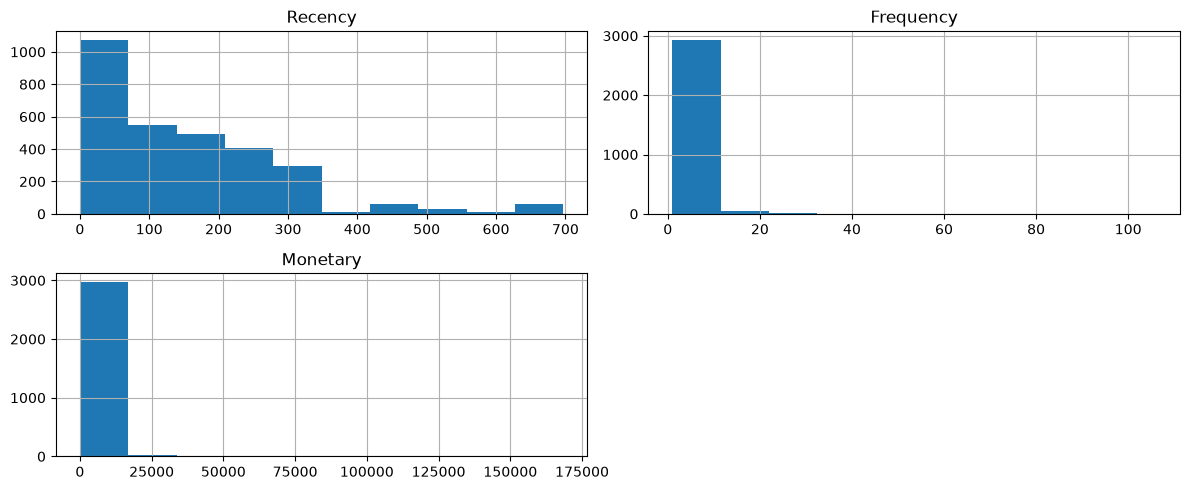

In [29]:
rfm[['Recency', 'Frequency', 'Monetary']].hist(figsize=(12,5))

plt.tight_layout()

plt.show()

Plot Boxplots

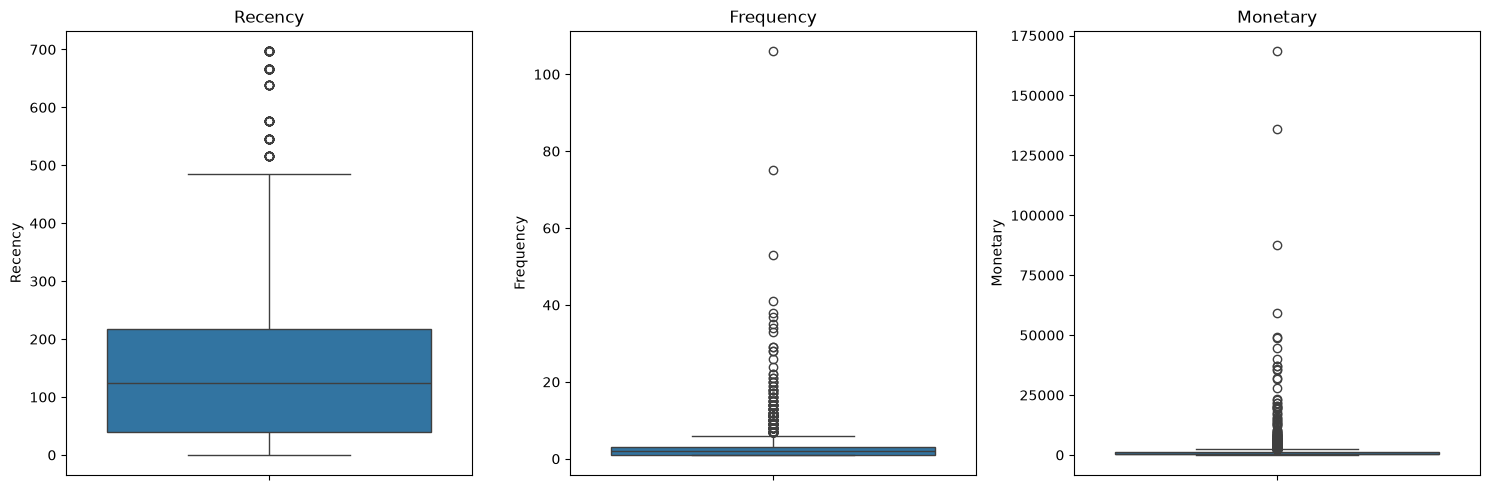

In [30]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=rfm['Recency'])
plt.title("Recency")

plt.subplot(1,3,2)
sns.boxplot(y=rfm['Frequency'])
plt.title("Frequency")

plt.subplot(1,3,3)
sns.boxplot(y=rfm['Monetary'])
plt.title("Monetary")

plt.tight_layout()

plt.show()

📌Task 2 – Analyze Relationships Between RFM Variables

Correlation Matrix

In [31]:
rfm[['Recency', 'Frequency', 'Monetary']].corr()

,Recency,Frequency,Monetary
Recency,1.000000,-0.254601,-0.118630
Frequency,-0.254601,1.000000,0.450596
Monetary,-0.118630,0.450596,1.000000


Store Correlation Matrix

In [32]:
corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()

corr

,Recency,Frequency,Monetary
Recency,1.000000,-0.254601,-0.118630
Frequency,-0.254601,1.000000,0.450596
Monetary,-0.118630,0.450596,1.000000


Correlation Heatmap

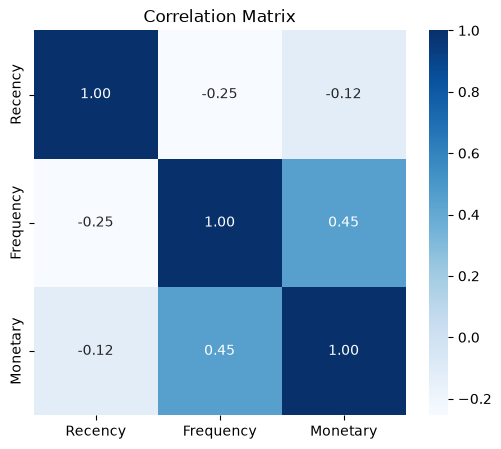

In [33]:
plt.figure(figsize=(6,5))

sns.heatmap(corr,
            annot=True,
            cmap='Blues',
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

Scatter Plot (Recency vs Frequency)

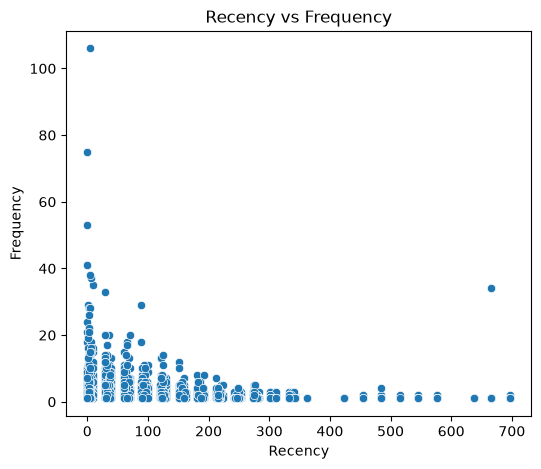

In [34]:
plt.figure(figsize=(6,5))

sns.scatterplot(data=rfm,
                x='Recency',
                y='Frequency')

plt.title("Recency vs Frequency")

plt.show()

Scatter Plot (Frequency vs Monetary)

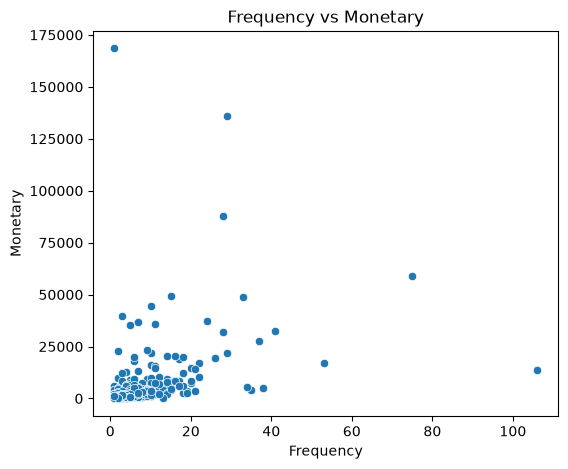

In [35]:
plt.figure(figsize=(6,5))

sns.scatterplot(data=rfm,
                x='Frequency',
                y='Monetary')

plt.title("Frequency vs Monetary")

plt.show()

Scatter Plot (Recency vs Monetary)

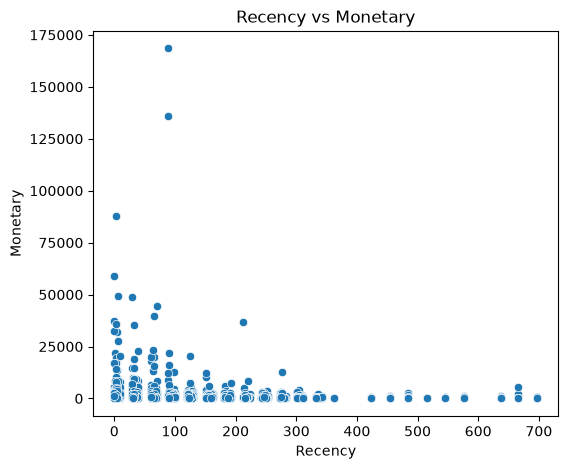

In [36]:
plt.figure(figsize=(6,5))

sns.scatterplot(data=rfm,
                x='Recency',
                y='Monetary')

plt.title("Recency vs Monetary")

plt.show()

📌 Week 2 – Task 3
Normalize the RFM Data

Import StandardScaler

In [37]:
from sklearn.preprocessing import StandardScaler

Select RFM Features

In [38]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

In [39]:
rfm_features.head()

,Recency,Frequency,Monetary
0,95,5,2540.29
1,220,1,367.00
2,311,1,334.40
3,274,3,1296.38
4,96,1,459.40


Create StandardScaler Object

In [40]:
scaler = StandardScaler()

Scale the Data

In [41]:
rfm_scaled = scaler.fit_transform(rfm_features)

Convert Back to DataFrame

In [42]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

Display First Rows

In [43]:
rfm_scaled.head()

,Recency,Frequency,Monetary
0,-0.424048,0.584713,0.237193
1,0.468022,-0.413228,-0.175029
2,1.117449,-0.413228,-0.181213
3,0.853396,0.085742,0.001252
4,-0.416911,-0.413228,-0.157503


Verify Mean

Round 1 and 2 
untill 0...

In [47]:
rfm_scaled.mean()

Recency      5.215863e-17
Frequency    3.496999e-17
Monetary    -1.778135e-18
dtype: float64

In [46]:
rfm_scaled.mean().round(2)

Recency      0.0
Frequency    0.0
Monetary    -0.0
dtype: float64

Verify Standard Deviation

In [45]:
rfm_scaled.std()

Recency      1.000167
Frequency    1.000167
Monetary     1.000167
dtype: float64

📌 Week 2 – Task 4
Determine the Optimal Number of Clusters (Elbow Method)

Import KMeans

In [48]:
from sklearn.cluster import KMeans

Create an Empty List

In [49]:
wcss = []

Calculate WCSS for Different K Values

In [50]:
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    
    wcss.append(kmeans.inertia_)

Display WCSS Values

In [52]:
print(wcss)

[8991.0, 6484.353164886146, 4537.358617180811, 3416.591529054598, 2703.0296204362926, 2056.909263347358, 1608.31060774305, 1394.7595217594917, 1191.797463914148, 1005.041046664734]


Plot the Elbow Curve

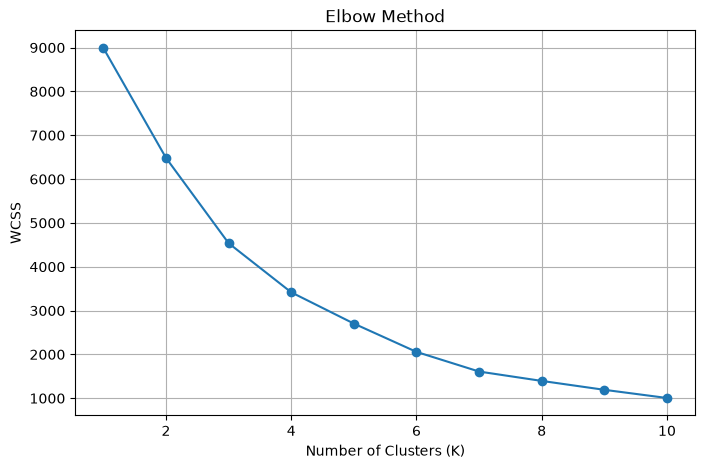

In [53]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

The curve drops sharply from:

K = 1 → 2
K = 2 → 3
K = 3 → 4

After K = 4, the decrease becomes much slower and smoother.

    Optimal Number of Clusters = 4

📌 Week 2 – Task 5
Apply K-Means Clustering

Import KMeans

In [54]:
from sklearn.cluster import KMeans

Initialize the K-Means Model

In [55]:
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42,
    n_init=10
)

Train the Model and Predict Clusters

In [56]:
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

View the First Few Records

In [57]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12347.0,95,5,2540.29,0
1,12348.0,220,1,367.00,1
2,12350.0,311,1,334.40,1
3,12352.0,274,3,1296.38,1
4,12355.0,96,1,459.40,0


Check the Number of Customers in Each Cluster

In [58]:
rfm['Cluster'].value_counts()

Cluster
0    2083
1     862
2      49
3       3
Name: count, dtype: int64

Save the Updated Dataset

In [60]:
rfm.to_csv("RFM_Clustered.csv", index=False)

📌 Week 2 – Task 6: Analyze Customer Segments

Calculate Cluster Summary

In [61]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
})

cluster_summary.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,85.45,2.73,1046.82
1,327.71,1.28,443.98
2,43.73,22.53,18575.11
3,60.00,19.33,130680.01


Count Customers in Each Cluster

In [62]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    2083
1     862
2      49
3       3
Name: count, dtype: int64

Combine Customer Count with Cluster Summary

In [63]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Customer ID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
})

cluster_summary.rename(columns={'Customer ID': 'Customers'}, inplace=True)

cluster_summary.round(2)

,Customers,Recency,Frequency,Monetary
Cluster,,,,
0,2083,85.45,2.73,1046.82
1,862,327.71,1.28,443.98
2,49,43.73,22.53,18575.11
3,3,60.00,19.33,130680.01


In [64]:
cluster_summary.round(2)

,Customers,Recency,Frequency,Monetary
Cluster,,,,
0,2083,85.45,2.73,1046.82
1,862,327.71,1.28,443.98
2,49,43.73,22.53,18575.11
3,3,60.00,19.33,130680.01


📌 Week 2 – Task 7: Assign Customer Personas

Create a Persona Dictionary

In [65]:
persona = {
    0: "Regular Customers",
    1: "Lost Customers",
    2: "Champions",
    3: "VIP Customers"
}

Map Personas to the Cluster Column

In [66]:
rfm["Customer Persona"] = rfm["Cluster"].map(persona)

Verify the Result

In [67]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Customer Persona
0,12347.0,95,5,2540.29,0,Regular Customers
1,12348.0,220,1,367.00,1,Lost Customers
2,12350.0,311,1,334.40,1,Lost Customers
3,12352.0,274,3,1296.38,1,Lost Customers
4,12355.0,96,1,459.40,0,Regular Customers


Count Customers in Each Persona

In [68]:
rfm["Customer Persona"].value_counts()

Customer Persona
Regular Customers    2083
Lost Customers        862
Champions              49
VIP Customers           3
Name: count, dtype: int64

Display Cluster Summary with Personas

In [69]:
cluster_summary = rfm.groupby("Customer Persona").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "Customer ID": "count"
})

cluster_summary.rename(columns={"Customer ID": "Customers"}, inplace=True)

cluster_summary.round(2)

,Recency,Frequency,Monetary,Customers
Customer Persona,,,,
Champions,43.73,22.53,18575.11,49
Lost Customers,327.71,1.28,443.98,862
Regular Customers,85.45,2.73,1046.82,2083
VIP Customers,60.00,19.33,130680.01,3


📌 Week 2 – Task 8: Visualize Customer Segments

Import Libraries

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

Frequency vs Monetary

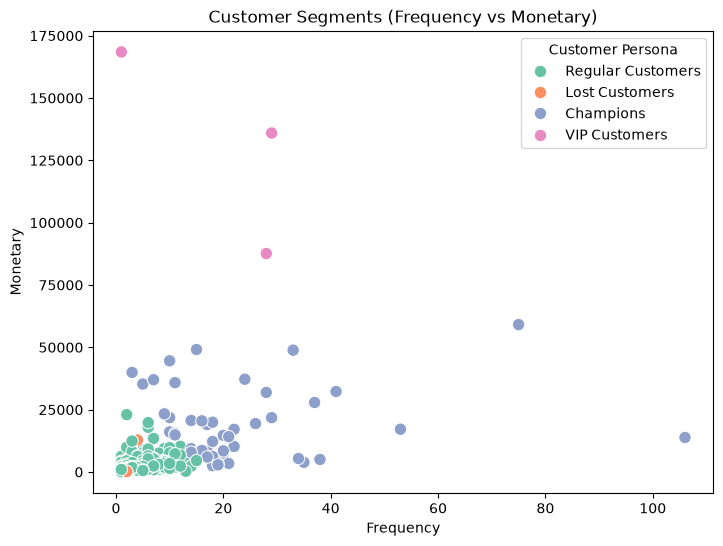

In [71]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Customer Persona',
    palette='Set2',
    s=80
)

plt.title("Customer Segments (Frequency vs Monetary)")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

Recency vs Frequency

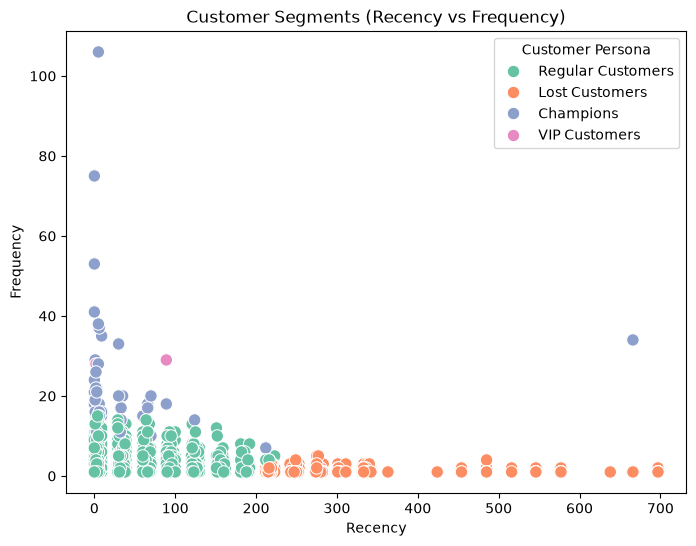

In [72]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Customer Persona',
    palette='Set2',
    s=80
)

plt.title("Customer Segments (Recency vs Frequency)")
plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.show()

Recency vs Monetary

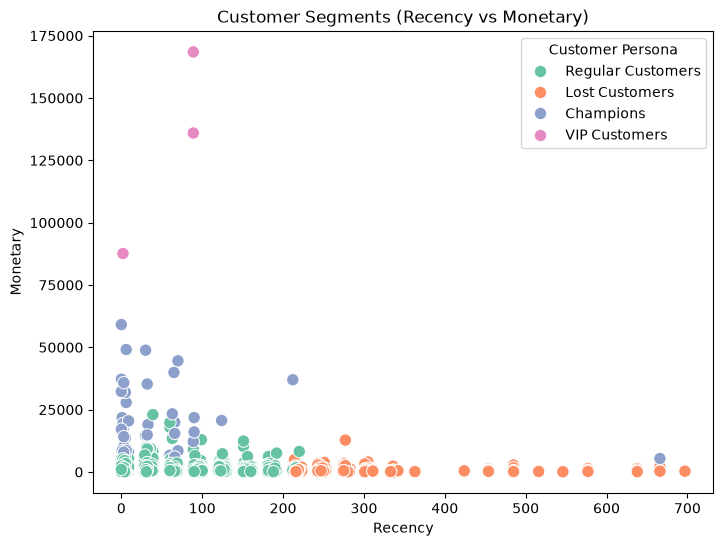

In [73]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Customer Persona',
    palette='Set2',
    s=80
)

plt.title("Customer Segments (Recency vs Monetary)")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

📌 Week 2 – Task 9: Save the Segmented Dataset

Verify the Dataset

In [74]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Customer Persona
0,12347.0,95,5,2540.29,0,Regular Customers
1,12348.0,220,1,367.00,1,Lost Customers
2,12350.0,311,1,334.40,1,Lost Customers
3,12352.0,274,3,1296.38,1,Lost Customers
4,12355.0,96,1,459.40,0,Regular Customers


Save as CSV

In [75]:
rfm.to_csv("RFM_Segmented_Dataset.csv", index=False)

Verify the File

In [76]:
import os

os.path.exists("RFM_Segmented_Dataset.csv")

True

Load the Saved File

In [77]:
saved_data = pd.read_csv("RFM_Segmented_Dataset.csv")

saved_data.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Customer Persona
0,12347.0,95,5,2540.29,0,Regular Customers
1,12348.0,220,1,367.00,1,Lost Customers
2,12350.0,311,1,334.40,1,Lost Customers
3,12352.0,274,3,1296.38,1,Lost Customers
4,12355.0,96,1,459.40,0,Regular Customers
